In [1]:
import os
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import accuracy_score, classification_report, roc_auc_score
from sklearn.metrics import confusion_matrix

from xgboost import XGBClassifier
import joblib

In [2]:
DATA_PATH = "../data/predictive_maintenance.csv"

df = pd.read_csv(DATA_PATH)

df.head()

,UDI,Product ID,Type,Air temperature [K],Process temperature [K],Rotational speed [rpm],Torque [Nm],Tool wear [min],Machine failure,TWF,HDF,PWF,OSF,RNF
0,1,M14860,M,298.1,308.6,1551,42.8,0,0,0,0,0,0,0
1,2,L47181,L,298.2,308.7,1408,46.3,3,0,0,0,0,0,0
2,3,L47182,L,298.1,308.5,1498,49.4,5,0,0,0,0,0,0
3,4,L47183,L,298.2,308.6,1433,39.5,7,0,0,0,0,0,0
4,5,L47184,L,298.2,308.7,1408,40.0,9,0,0,0,0,0,0


In [3]:
# Drop useless columns
df = df.drop(['UDI', 'Product ID'], axis=1)

# Encode Type column
df['Type'] = df['Type'].map({'L': 0, 'M': 1, 'H': 2})

# Check
df.head()

,Type,Air temperature [K],Process temperature [K],Rotational speed [rpm],Torque [Nm],Tool wear [min],Machine failure,TWF,HDF,PWF,OSF,RNF
0,1,298.1,308.6,1551,42.8,0,0,0,0,0,0,0
1,0,298.2,308.7,1408,46.3,3,0,0,0,0,0,0
2,0,298.1,308.5,1498,49.4,5,0,0,0,0,0,0
3,0,298.2,308.6,1433,39.5,7,0,0,0,0,0,0
4,0,298.2,308.7,1408,40.0,9,0,0,0,0,0,0


In [4]:
X = df.drop('Machine failure', axis=1)
y = df['Machine failure']

In [5]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

In [6]:
scaler = StandardScaler()

X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

In [7]:
model = XGBClassifier(
    n_estimators=200,
    max_depth=5,
    learning_rate=0.1,
    subsample=0.8,
    colsample_bytree=0.8,
    eval_metric='logloss'
)

model.fit(X_train_scaled, y_train)

XGBClassifier(base_score=None, booster=None, callbacks=None,
              colsample_bylevel=None, colsample_bynode=None,
              colsample_bytree=0.8, device=None, early_stopping_rounds=None,
              enable_categorical=False, eval_metric='logloss',
              feature_types=None, feature_weights=None, gamma=None,
              grow_policy=None, importance_type=None,
              interaction_constraints=None, learning_rate=0.1, max_bin=None,
              max_cat_threshold=None, max_cat_to_onehot=None,
              max_delta_step=None, max_depth=5, max_leaves=None,
              min_child_weight=None, missing=nan, monotone_constraints=None,
              multi_strategy=None, n_estimators=200, n_jobs=None,
              num_parallel_tree=None, ...)

In [8]:
y_pred = model.predict(X_test_scaled)
y_proba = model.predict_proba(X_test_scaled)[:,1]

print("Accuracy:", accuracy_score(y_test, y_pred))
print("ROC-AUC:", roc_auc_score(y_test, y_proba))

print("\nClassification Report:\n")
print(classification_report(y_test, y_pred))

Accuracy: 0.9985
ROC-AUC: 0.9965214346608209

Classification Report:

              precision    recall  f1-score   support

           0       1.00      1.00      1.00      1932
           1       1.00      0.96      0.98        68

    accuracy                           1.00      2000
   macro avg       1.00      0.98      0.99      2000
weighted avg       1.00      1.00      1.00      2000



In [9]:
# df = df.drop(['TWF', 'HDF', 'PWF', 'OSF', 'RNF'], axis=1)

In [10]:
df['Type'] = df['Type'].map({'L': 0, 'M': 1, 'H': 2})

# Split
X = df.drop('Machine failure', axis=1)
y = df['Machine failure']

In [11]:
y_pred = model.predict(X_test_scaled)
y_proba = model.predict_proba(X_test_scaled)[:,1]

print("Accuracy:", accuracy_score(y_test, y_pred))
print("ROC-AUC:", roc_auc_score(y_test, y_proba))

print("\nClassification Report:\n")
print(classification_report(y_test, y_pred))

Accuracy: 0.9985
ROC-AUC: 0.9965214346608209

Classification Report:

              precision    recall  f1-score   support

           0       1.00      1.00      1.00      1932
           1       1.00      0.96      0.98        68

    accuracy                           1.00      2000
   macro avg       1.00      0.98      0.99      2000
weighted avg       1.00      1.00      1.00      2000



In [12]:
print(X.columns)

Index(['Type', 'Air temperature [K]', 'Process temperature [K]',
       'Rotational speed [rpm]', 'Torque [Nm]', 'Tool wear [min]', 'TWF',
       'HDF', 'PWF', 'OSF', 'RNF'],
      dtype='object')


In [13]:
cm = confusion_matrix(y_test, y_pred)
print(cm)

[[1932    0]
 [   3   65]]


In [14]:
print(y.value_counts())

Machine failure
0    9661
1     339
Name: count, dtype: int64


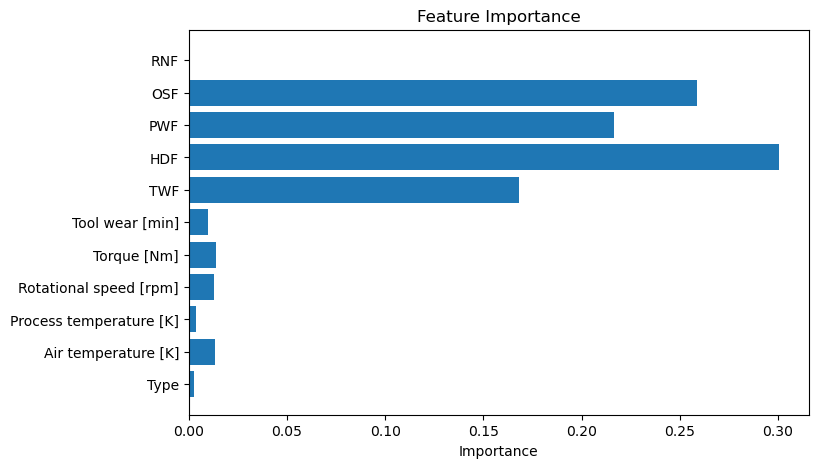

In [15]:
importances = model.feature_importances_
features = list(X.columns)

plt.figure(figsize=(8,5))
plt.barh(features, importances)
plt.xlabel("Importance")
plt.title("Feature Importance")
plt.show()

In [18]:
df = df.copy()

In [20]:
# Load dataset
df = pd.read_csv(DATA_PATH)

# Drop columns
df = df.drop(['UDI', 'Product ID', 'TWF', 'HDF', 'PWF', 'OSF', 'RNF'], axis=1)

# Encode
df['Type'] = df['Type'].map({'L': 0, 'M': 1, 'H': 2})

# Split
X = df.drop('Machine failure', axis=1)
y = df['Machine failure']

print("Final Features:", X.columns)
print("Total Features:", len(X.columns))  # MUST be 6

Final Features: Index(['Type', 'Air temperature [K]', 'Process temperature [K]',
       'Rotational speed [rpm]', 'Torque [Nm]', 'Tool wear [min]'],
      dtype='object')
Total Features: 6


In [22]:
df = df.copy()

df['Type'] = df['Type'].map({'L': 0, 'M': 1, 'H': 2})

X = df.drop('Machine failure', axis=1)
y = df['Machine failure']

In [23]:
print(X.columns)
print(len(X.columns))

Index(['Type', 'Air temperature [K]', 'Process temperature [K]',
       'Rotational speed [rpm]', 'Torque [Nm]', 'Tool wear [min]'],
      dtype='object')
6


In [26]:
model = XGBClassifier(
    n_estimators=200,
    max_depth=5,
    learning_rate=0.1,
    eval_metric='logloss'
)

model.fit(X_train_scaled, y_train)

print("Features in model:", len(model.feature_importances_))

Features in model: 11


In [27]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

# Scale AGAIN
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

print("Shape:", X_train_scaled.shape) 

Shape: (8000, 6)


c:\Users\Habibullah\anaconda3\Lib\site-packages\sklearn\utils\extmath.py:1101: RuntimeWarning: invalid value encountered in divide
  updated_mean = (last_sum + new_sum) / updated_sample_count
c:\Users\Habibullah\anaconda3\Lib\site-packages\sklearn\utils\extmath.py:1106: RuntimeWarning: invalid value encountered in divide
  T = new_sum / new_sample_count
c:\Users\Habibullah\anaconda3\Lib\site-packages\sklearn\utils\extmath.py:1126: RuntimeWarning: invalid value encountered in divide
  new_unnormalized_variance -= correction**2 / new_sample_count


In [28]:
model = XGBClassifier(
    n_estimators=200,
    max_depth=5,
    learning_rate=0.1,
    eval_metric='logloss'
)

model.fit(X_train_scaled, y_train)

print("Features in model:", len(model.feature_importances_))

Features in model: 6


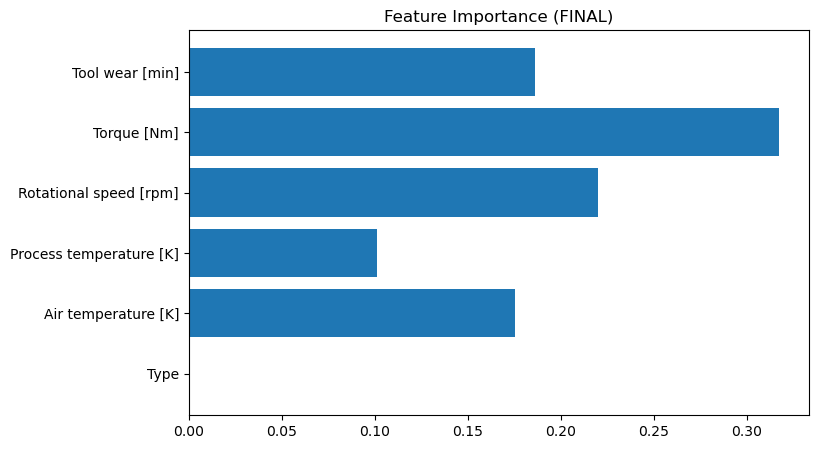

In [29]:
plt.figure(figsize=(8,5))
plt.barh(X.columns, model.feature_importances_)
plt.title("Feature Importance (FINAL)")
plt.show()

In [34]:
# Test prediction
y_pred = model.predict(X_test_scaled)
y_proba = model.predict_proba(X_test_scaled)[:, 1]

print("Accuracy:", accuracy_score(y_test, y_pred))
print("ROC-AUC:", roc_auc_score(y_test, y_proba))
print(classification_report(y_test, y_pred))
cm = confusion_matrix(y_test, y_pred)
print(cm)

Accuracy: 0.9865
ROC-AUC: 0.9789687614176106
              precision    recall  f1-score   support

           0       0.99      1.00      0.99      1932
           1       0.90      0.68      0.77        68

    accuracy                           0.99      2000
   macro avg       0.95      0.84      0.88      2000
weighted avg       0.99      0.99      0.99      2000

[[1927    5]
 [  22   46]]


In [35]:
model = XGBClassifier(
    n_estimators=300,
    max_depth=6,
    learning_rate=0.05,
    scale_pos_weight= (len(y_train[y_train==0]) / len(y_train[y_train==1])),
    eval_metric='logloss'
)

In [38]:
model.fit(X_train_scaled, y_train)

XGBClassifier(base_score=None, booster=None, callbacks=None,
              colsample_bylevel=None, colsample_bynode=None,
              colsample_bytree=None, device=None, early_stopping_rounds=None,
              enable_categorical=False, eval_metric='logloss',
              feature_types=None, feature_weights=None, gamma=None,
              grow_policy=None, importance_type=None,
              interaction_constraints=None, learning_rate=0.05, max_bin=None,
              max_cat_threshold=None, max_cat_to_onehot=None,
              max_delta_step=None, max_depth=6, max_leaves=None,
              min_child_weight=None, missing=nan, monotone_constraints=None,
              multi_strategy=None, n_estimators=300, n_jobs=None,
              num_parallel_tree=None, ...)

In [39]:
y_proba = model.predict_proba(X_test_scaled)[:, 1]

# Apply threshold
y_pred = (y_proba > 0.3).astype(int)

In [40]:
from sklearn.metrics import accuracy_score, roc_auc_score, classification_report, confusion_matrix

print("Accuracy:", accuracy_score(y_test, y_pred))
print("ROC-AUC:", roc_auc_score(y_test, y_proba))

print(classification_report(y_test, y_pred))

cm = confusion_matrix(y_test, y_pred)
print(cm)

Accuracy: 0.9725
ROC-AUC: 0.9720725246620388
              precision    recall  f1-score   support

           0       0.99      0.98      0.99      1932
           1       0.57      0.78      0.66        68

    accuracy                           0.97      2000
   macro avg       0.78      0.88      0.82      2000
weighted avg       0.98      0.97      0.97      2000

[[1892   40]
 [  15   53]]


In [41]:
os.makedirs("../models", exist_ok=True)

joblib.dump(model, "../models/model.pkl")
joblib.dump(scaler, "../models/scaler.pkl")

print("Model saved successfully ✅")

Model saved successfully ✅
